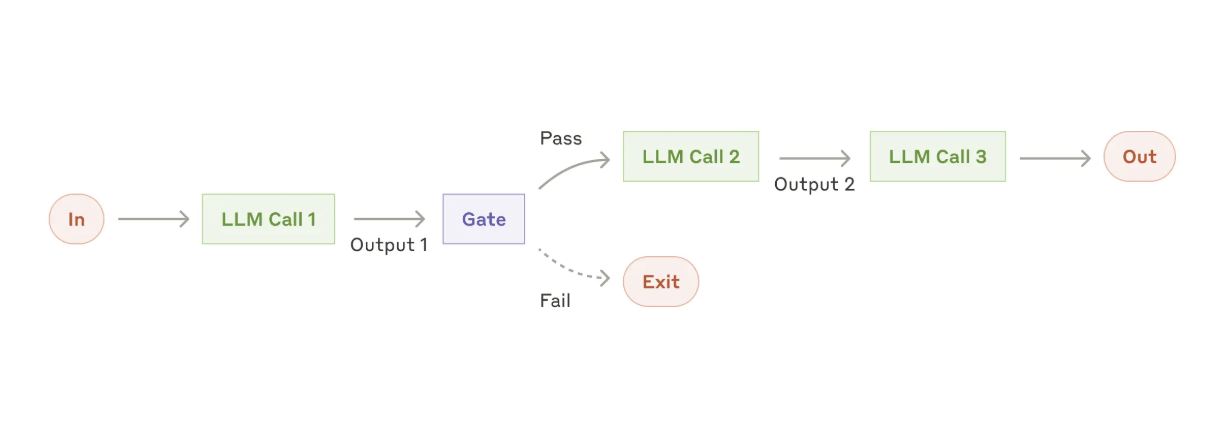

<a href="https://langchain-ai.github.io/langgraph/tutorials/workflows/">Source</a>

# 0.0. Configure

In [ ]:
from dotenv import load_dotenv

In [ ]:
load_dotenv()

True

# 1.0. Imports

In [23]:
from IPython.display import Image, display

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

# 2.0. Hands-On

In [4]:
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

In [7]:
llm = ChatOpenAI(model="gpt-4o")

In [8]:
def generate_joke(state: State):
    """First LLM call to generate a joke"""

    msg = llm.invoke(f"Write a shot joke about {state['topic']}")

    return { "joke": msg.content}

def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    if '?' in state['joke'] or '!' in state['joke']:
        return "Pass"
    
    return "Fail"

def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")

    return { "improved_joke": msg.content }

def polish_joke(state: State):
    """Third LLM call for final polish"""

    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")

    return { "final_joke": msg.content }

In [12]:
workflow = StateGraph(State)

workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

workflow.add_edge(START, "generate_joke")

workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Pass": "improve_joke", "Fail": END}
)

workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

chain = workflow.compile()

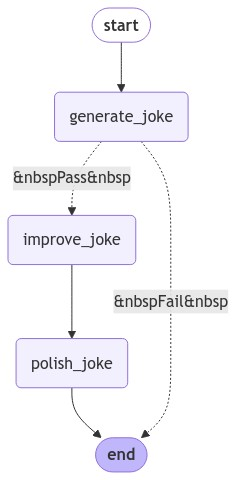

In [18]:
display(Image(chain.get_graph().draw_mermaid_png()))

# 3.0. Testing

In [19]:
state = chain.invoke({"topic": "elephants"})

In [20]:
state["joke"]

'Why don’t elephants use computers?  \nBecause they’re afraid of the mouse!'

In [21]:
state["improved_joke"]

"Why don't elephants use computers?  \nBecause they're terrified they'll lose their memory when they see the RAM!"

In [22]:
state["final_joke"]

"Why don't elephants use computers?  \nBecause they're terrified they'll lose their memory when they see the RAM! But the real reason? They actually prefer tablets—they double as extra-large peanut trays!"